**1. What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.**

It is one of the types of algorithms, and this type of algorithm falls into the unsupervised Machine Learning style, because the target variable will not be used.

Types of Anomalies:
1. Point Anomaly

A single data point is very different from the rest.

Example:

In a daily transaction dataset where most values are around ₹500–₹2000, one value is ₹1,00,000 — this is a point anomaly.

2. Contextual Anomaly

A data point is normal in general, but anomalous in a specific context (time, location, season).

Example:

Temperature of 30°C is normal in summer,

but 30°C in winter is an anomaly.

Context = season or time.

3. Collective Anomaly

A group of data points together forms an anomaly, even if individual points may look normal.

Example:

In a server log, a sudden burst of 10,000 requests in 2 seconds is a collective anomaly, indicating a cyber attack (DDoS).

The sequence itself is suspicious.


Algorithms Used for Anomaly Detection::

1. Isolation Forest:
- Isolation means -->Multiple isolation trees
- Isolation tree is like a decision tree


2. DBSCAN:
- Density-Based Spatial Clustering of Applications with Noise
- It is for clustering
- Also, it will find outliers
- And it is density based algorithm


3. Local Outlier Factor anomaly detection:

LOF detects anomalies by comparing the local density of a point with the density of its neighbors.

Two types:

Local Outlier

Global Outlier

Points with high distance from neighbors = lower density = more likely to be outliers.

**2. Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.**

**Isolation Forest**

Tree-based method.

Isolates points using random splits.

Faster and works well on high-dimensional data.

Best for large datasets and numerical features.

**DBSCAN**

Density-based clustering + anomaly detection.

Points in low-density areas = outliers.

Works well for spatial datasets (2D, 3D).

Not good for high-dimensional data.

**Local Outlier Factor (LOF)**

Compares local density of each point with neighbors.

Good for finding local outliers.

Works well when data varies in density.

Slower than Isolation Forest for large datasets.

**3.  What are the key components of a Time Series? Explain each with one example.**

**Trend:**

Overall long-term upward or downward movement.
Example: Increasing number of airline passengers over years.

**Seasonality:**

Repeated pattern over a fixed period (daily, monthly).
Example: Ice cream sales increase every summer.

**Cyclic Component:**

Irregular cycles, not fixed like seasonality.
Example: Economic ups and downs.

**Residual / Noise:**

Random variation that cannot be explained.
Example: Sudden spikes due to holidays.

**4. Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?**

A time series is stationary if its mean, variance, and covariance remain constant over time.

***How to Test***

- ADF Test (Augmented Dickey-Fuller)

- KPSS Test

- Plot ACF/PACF

- Visual inspection (trend, seasonality)

**How to Convert Non-stationary to Stationary**

- Differencing (1st or 2nd order)

- Log transform

- Seasonal differencing

- Box–Cox transformation

**5. Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.**

**AR (Auto-Regressive)**

Uses past values to predict future values.

Example: AR(2) uses last 2 values.

**MA (Moving Average)**

Uses past error terms for prediction.

Example: MA(1) uses last 1 error.

**ARIMA (AR + I + MA)**

I = Differencing (to make series stationary)

Used for non-seasonal time series.

**SARIMA**

ARIMA + Seasonal components

Used for seasonal time series.

**SARIMAX**

SARIMA + Exogenous (external) variables

Example: Forecasting sales using marketing budget + seasonality.

**6.  Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components.**

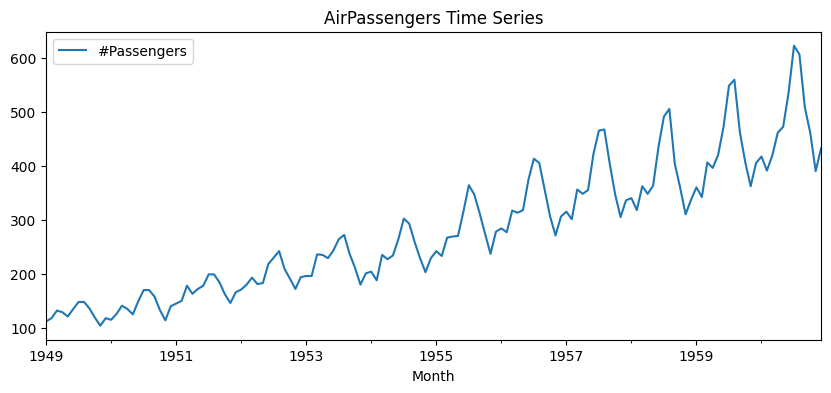

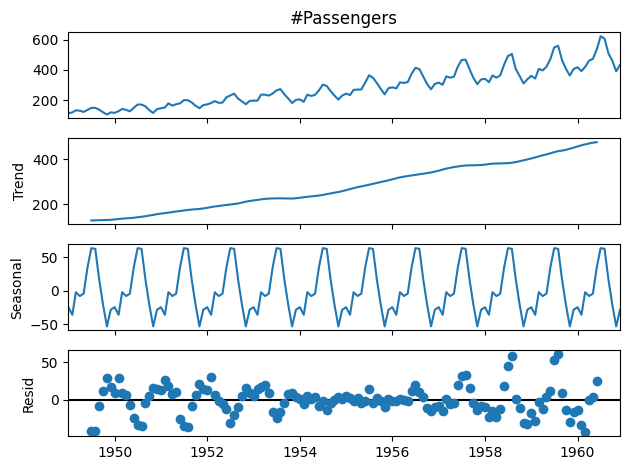

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# Plot original series
df.plot(figsize=(10,4))
plt.title("AirPassengers Time Series")
plt.show()

# Decomposition
result = seasonal_decompose(df['#Passengers'], model='additive')
result.plot()
plt.show()

In [3]:
print(df.columns)


Index(['#Passengers'], dtype='object')


**7. Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to detect anomalies. Visualize the anomalies on a 2D scatter plot.**

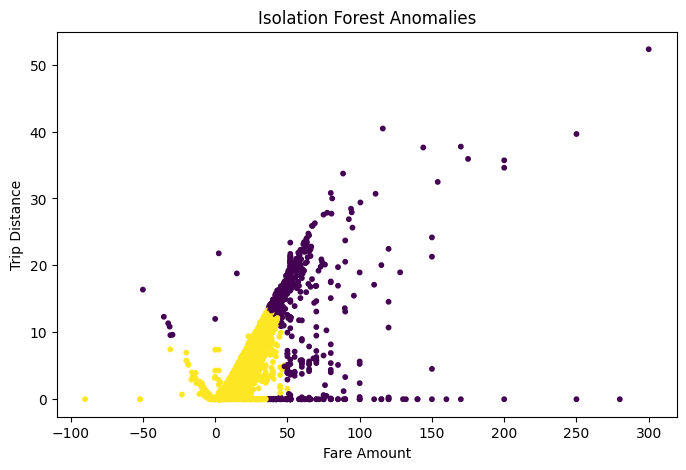

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Load dataset
df = pd.read_csv('/content/NYC_taxi_fare_data.csv')

# Select numerical features
X = df[['fare_amount', 'trip_distance']]

# Train Isolation Forest
model = IsolationForest(contamination=0.02)
df['anomaly'] = model.fit_predict(X)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(df['fare_amount'], df['trip_distance'], c=df['anomaly'], s=10)
plt.xlabel("Fare Amount")
plt.ylabel("Trip Distance")
plt.title("Isolation Forest Anomalies")
plt.show()


**8. Train a SARIMA model on the monthly airline passengers dataset. Forecast the next 12 months and visualize the results.**

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


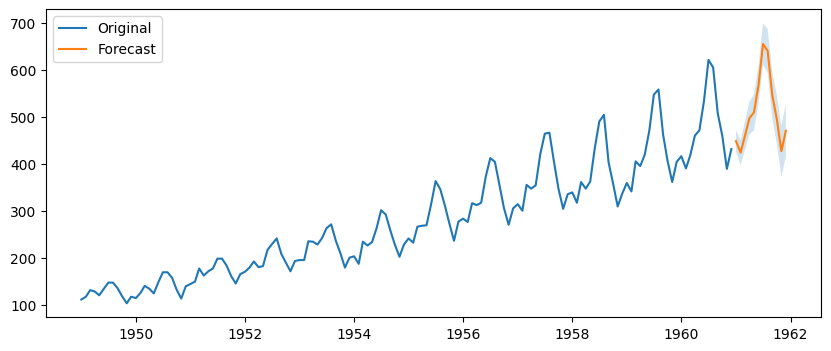

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'], index_col='Month')

# SARIMA model
model = SARIMAX(df['#Passengers'], order=(1,1,1), seasonal_order=(1,1,1,12))
result = model.fit()

# Forecast next 12 months
forecast = result.get_forecast(12)
pred = forecast.predicted_mean
conf = forecast.conf_int()

# Plot
plt.figure(figsize=(10,4))
plt.plot(df['#Passengers'], label='Original')
plt.plot(pred, label='Forecast')
plt.fill_between(conf.index, conf.iloc[:,0], conf.iloc[:,1], alpha=0.2)
plt.legend()
plt.show()


**9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect anomalies and visualize them using matplotlib.**

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


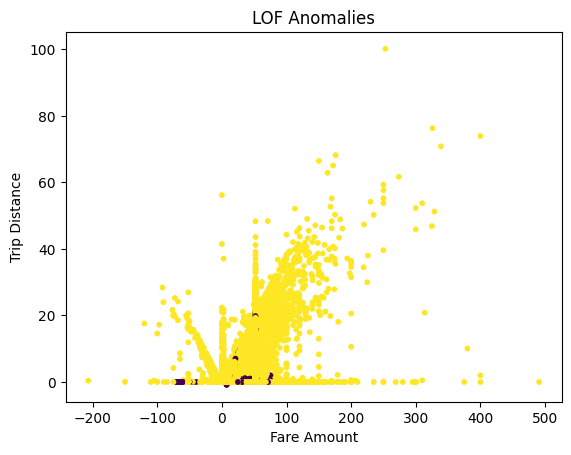

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

df = pd.read_csv('/content/NYC_taxi_fare_data.csv')

X = df[['fare_amount', 'trip_distance']]

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
df['anomaly'] = lof.fit_predict(X)

plt.scatter(df['fare_amount'], df['trip_distance'], c=df['anomaly'], s=10)
plt.xlabel("Fare Amount")
plt.ylabel("Trip Distance")
plt.title("LOF Anomalies")
plt.show()


10. You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and also detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.

**Explain your real-time data science workflow:**

 ● How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?

 ● Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)?

 ● How would you validate and monitor the performance over time?

 ● How would this solution help business decisions or operations?

**1. Anomaly Detection in Streaming Data**

**I would use Isolation Forest or LOF because:**

- They work well on continuous numerical data.

- Can detect sudden spikes, drops, or unusual patterns.

- Easy to update with new batches of data.

- For spatial clustering or region-based data, DBSCAN can also be used.

**2. Forecasting Model**

**I would use SARIMAX because:**

- It handles seasonality.

- It allows external factors like weather, region, temperature.

- Gives more accurate short-term forecasts.

**3. Validation and Monitoring**

- Train-test split on historical data.

- Use metrics: RMSE, MAPE, MAE.

- Monitor accuracy weekly or monthly.

- Set alert thresholds for anomalies.

**4. Business Impact**

- Prevents overload by predicting demand early.

- Detects sudden spikes → avoids power failures.

- Helps optimize energy distribution across regions.

- Reduces cost and improves grid stability.